# Exploratory Data Analysis
## UCI Online Shoppers Purchasing Intention Dataset

This notebook documents the analytical thinking that preceded the model-building pipeline.  
All preprocessing, feature engineering, and modelling decisions in `orchestrator.py` are grounded in findings from this analysis.

**Dataset:** 12,330 browsing sessions | 18 raw features | Binary target (Revenue)  
**Class balance:** 15.5% buyers, 84.5% non-buyers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.facecolor':  '#0a0a0f',
    'axes.facecolor':    '#12121a',
    'axes.edgecolor':    '#1e1e2e',
    'axes.labelcolor':   '#e8e8f0',
    'xtick.color':       '#5a5a7a',
    'ytick.color':       '#5a5a7a',
    'text.color':        '#e8e8f0',
    'grid.color':        '#1e1e2e',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
})

ACCENT  = '#e8ff47'
ACCENT2 = '#47ffe8'
DANGER  = '#ff4747'
COLD    = '#4799ff'
WARM    = '#ffaa47'
HOT     = '#ff6b47'
CONVERT = '#47ff8a'

df = pd.read_csv('../data/raw/online_shoppers_intention.csv')
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (12330, 18)

Dtypes:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 1. Class Distribution

The target variable `Revenue` is heavily imbalanced — only 15.5% of sessions result in a purchase.  
This directly motivates the use of **SMOTETomek** in preprocessing and **class-weighted loss** in the neural network.

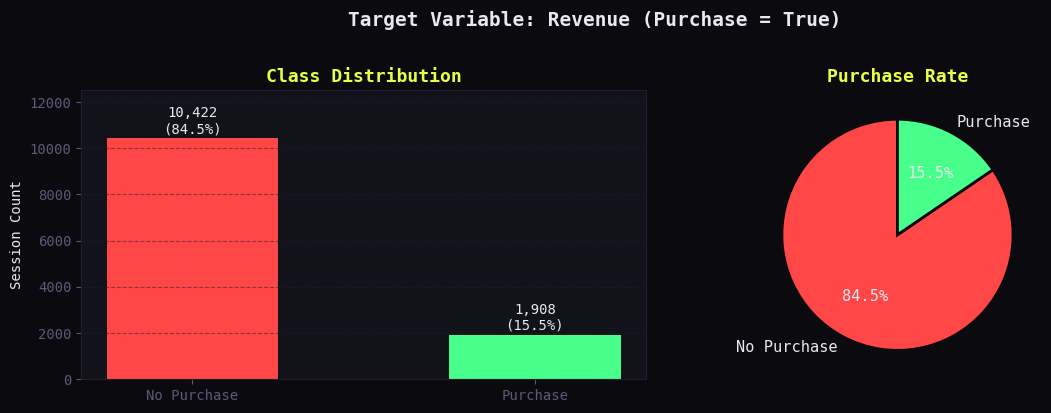

Imbalance ratio: 5.5:1 (non-buyers to buyers)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['Revenue'].value_counts()
colors = [DANGER, CONVERT]
bars   = axes[0].bar(
    ['No Purchase', 'Purchase'],
    counts.values,
    color=colors, edgecolor='none', width=0.5
)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold', color=ACCENT)
axes[0].set_ylabel('Session Count')
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{count:,}\n({count/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=10, color='#e8e8f0'
    )
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].grid(axis='y')

# Pie chart
axes[1].pie(
    counts.values,
    labels=['No Purchase', 'Purchase'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color': '#e8e8f0', 'fontsize': 11},
    wedgeprops={'edgecolor': '#0a0a0f', 'linewidth': 2}
)
axes[1].set_title('Purchase Rate', fontsize=13, fontweight='bold', color=ACCENT)

plt.suptitle(
    'Target Variable: Revenue (Purchase = True)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print(f"Imbalance ratio: {counts[False]/counts[True]:.1f}:1 (non-buyers to buyers)")

## 2. Purchase Rate by Month

Seasonality is one of the strongest signals in this dataset.  
November shows a dramatically higher purchase rate — Black Friday / Cyber Monday effect.  
This validates **Month** appearing as the second most important SHAP feature.

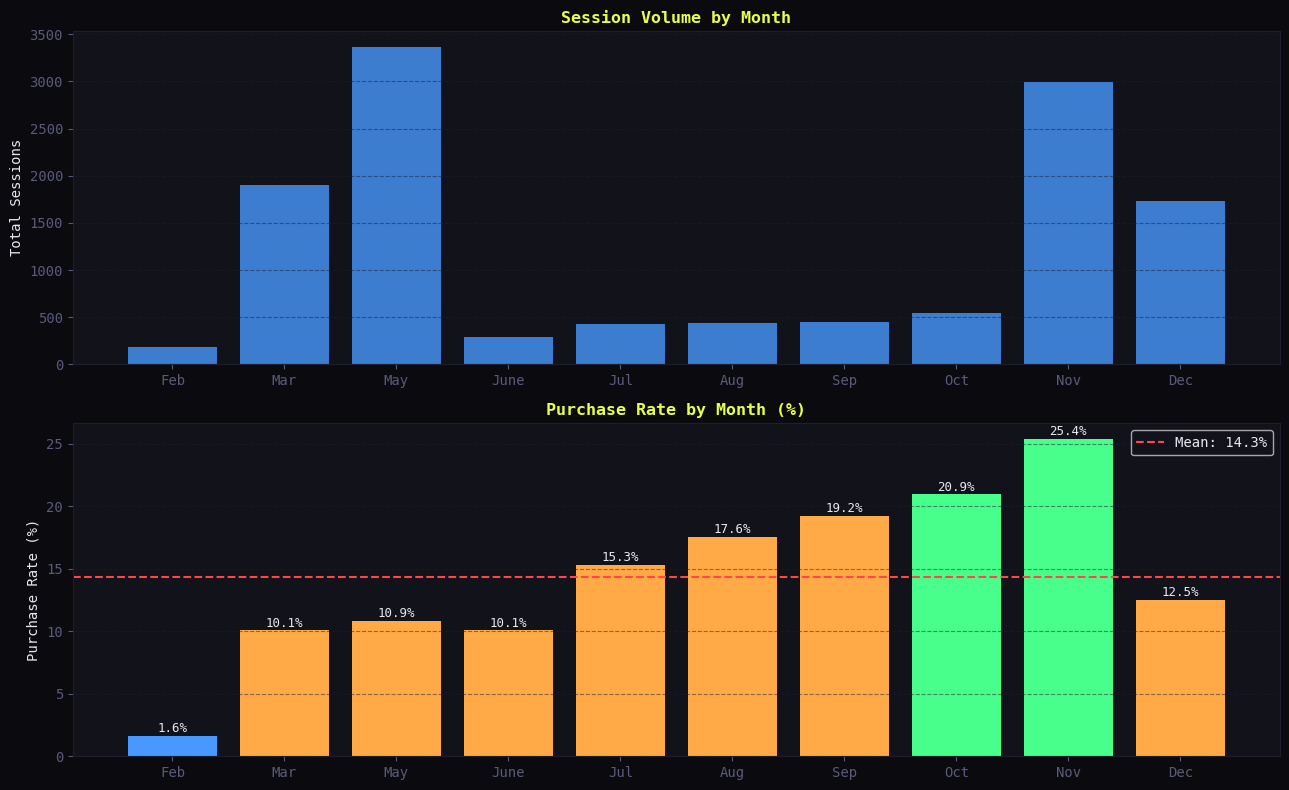

In [4]:
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_stats = df.groupby('Month').agg(
    total=('Revenue', 'count'),
    purchases=('Revenue', 'sum')
).reindex(month_order).dropna()
month_stats['rate'] = month_stats['purchases'] / month_stats['total'] * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Session volume
axes[0].bar(
    month_stats.index, month_stats['total'],
    color=COLD, alpha=0.8, edgecolor='none'
)
axes[0].set_title('Session Volume by Month', fontsize=12,
                   fontweight='bold', color=ACCENT)
axes[0].set_ylabel('Total Sessions')
axes[0].grid(axis='y')

# Purchase rate
bars = axes[1].bar(
    month_stats.index, month_stats['rate'],
    color=[CONVERT if r > 20 else WARM if r > 10 else COLD
           for r in month_stats['rate']],
    edgecolor='none'
)
axes[1].set_title('Purchase Rate by Month (%)',
                   fontsize=12, fontweight='bold', color=ACCENT)
axes[1].set_ylabel('Purchase Rate (%)')
axes[1].axhline(
    month_stats['rate'].mean(), color=DANGER,
    linestyle='--', linewidth=1.5,
    label=f"Mean: {month_stats['rate'].mean():.1f}%"
)
axes[1].legend()
axes[1].grid(axis='y')

for bar, rate in zip(bars, month_stats['rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{rate:.1f}%',
        ha='center', fontsize=9, color='#e8e8f0'
    )

plt.tight_layout()
plt.savefig('purchase_rate_by_month.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

## 3. Visitor Type Analysis

Returning visitors convert at a significantly higher rate than new visitors.  
This validates **VisitorType** as a useful feature and motivates the bandit recommender  
treating returning visitors as a separate context with different optimal actions.

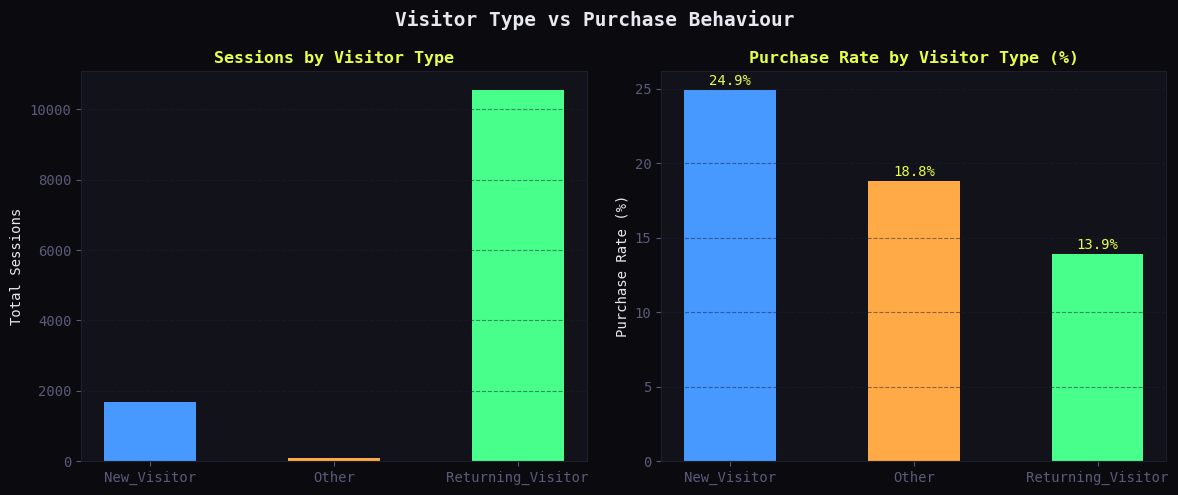

In [5]:
visitor_stats = df.groupby('VisitorType').agg(
    total=('Revenue', 'count'),
    purchases=('Revenue', 'sum')
)
visitor_stats['rate'] = visitor_stats['purchases'] / visitor_stats['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_v = [COLD, WARM, CONVERT]

axes[0].bar(
    visitor_stats.index, visitor_stats['total'],
    color=colors_v, edgecolor='none', width=0.5
)
axes[0].set_title('Sessions by Visitor Type',
                   fontsize=12, fontweight='bold', color=ACCENT)
axes[0].set_ylabel('Total Sessions')
axes[0].grid(axis='y')

axes[1].bar(
    visitor_stats.index, visitor_stats['rate'],
    color=colors_v, edgecolor='none', width=0.5
)
axes[1].set_title('Purchase Rate by Visitor Type (%)',
                   fontsize=12, fontweight='bold', color=ACCENT)
axes[1].set_ylabel('Purchase Rate (%)')
axes[1].grid(axis='y')
for i, (idx, row) in enumerate(visitor_stats.iterrows()):
    axes[1].text(
        i, row['rate'] + 0.3,
        f"{row['rate']:.1f}%",
        ha='center', fontsize=10, color=ACCENT
    )

plt.suptitle('Visitor Type vs Purchase Behaviour',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visitor_type_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

## 4. PageValues Distribution — The Strongest Feature

SHAP analysis identifies `PageValues` as the single most important feature.  
This plot shows why: buyers and non-buyers have dramatically different PageValues distributions.  
Buyers concentrate at higher values — they are visiting pages with real purchase intent.

Median PageValues — Buyers: 16.8 | Non-buyers: 0.0
Mean PageValues   — Buyers: 27.3 | Non-buyers: 2.0


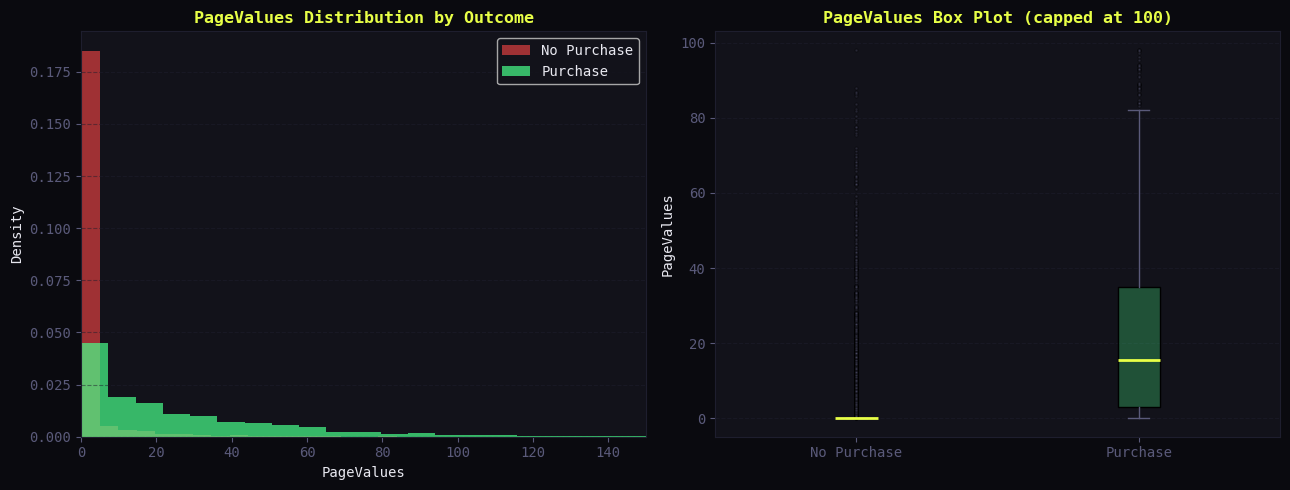

In [6]:
buyers     = df[df['Revenue'] == True]['PageValues']
non_buyers = df[df['Revenue'] == False]['PageValues']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution
axes[0].hist(
    non_buyers, bins=50, color=DANGER, alpha=0.6,
    label='No Purchase', density=True, edgecolor='none'
)
axes[0].hist(
    buyers, bins=50, color=CONVERT, alpha=0.7,
    label='Purchase', density=True, edgecolor='none'
)
axes[0].set_xlim(0, 150)
axes[0].set_title('PageValues Distribution by Outcome',
                   fontsize=12, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(axis='y')

# Box plot
data_to_plot = [
    non_buyers[non_buyers < 100].values,
    buyers[buyers < 100].values
]
bp = axes[1].boxplot(
    data_to_plot,
    labels=['No Purchase', 'Purchase'],
    patch_artist=True,
    medianprops={'color': ACCENT, 'linewidth': 2},
    whiskerprops={'color': '#5a5a7a'},
    capprops={'color': '#5a5a7a'},
    flierprops={'marker': 'o', 'markersize': 2,
                'markerfacecolor': '#5a5a7a', 'alpha': 0.3}
)
bp['boxes'][0].set_facecolor(DANGER + '44')
bp['boxes'][1].set_facecolor(CONVERT + '44')
axes[1].set_title('PageValues Box Plot (capped at 100)',
                   fontsize=12, fontweight='bold', color=ACCENT)
axes[1].set_ylabel('PageValues')
axes[1].grid(axis='y')

print(f"Median PageValues — Buyers: {buyers.median():.1f} | Non-buyers: {non_buyers.median():.1f}")
print(f"Mean PageValues   — Buyers: {buyers.mean():.1f} | Non-buyers: {non_buyers.mean():.1f}")

plt.tight_layout()
plt.savefig('pagevalues_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

## 5. Correlation Heatmap

Understanding feature correlations helps identify multicollinearity  
and guides feature selection decisions.

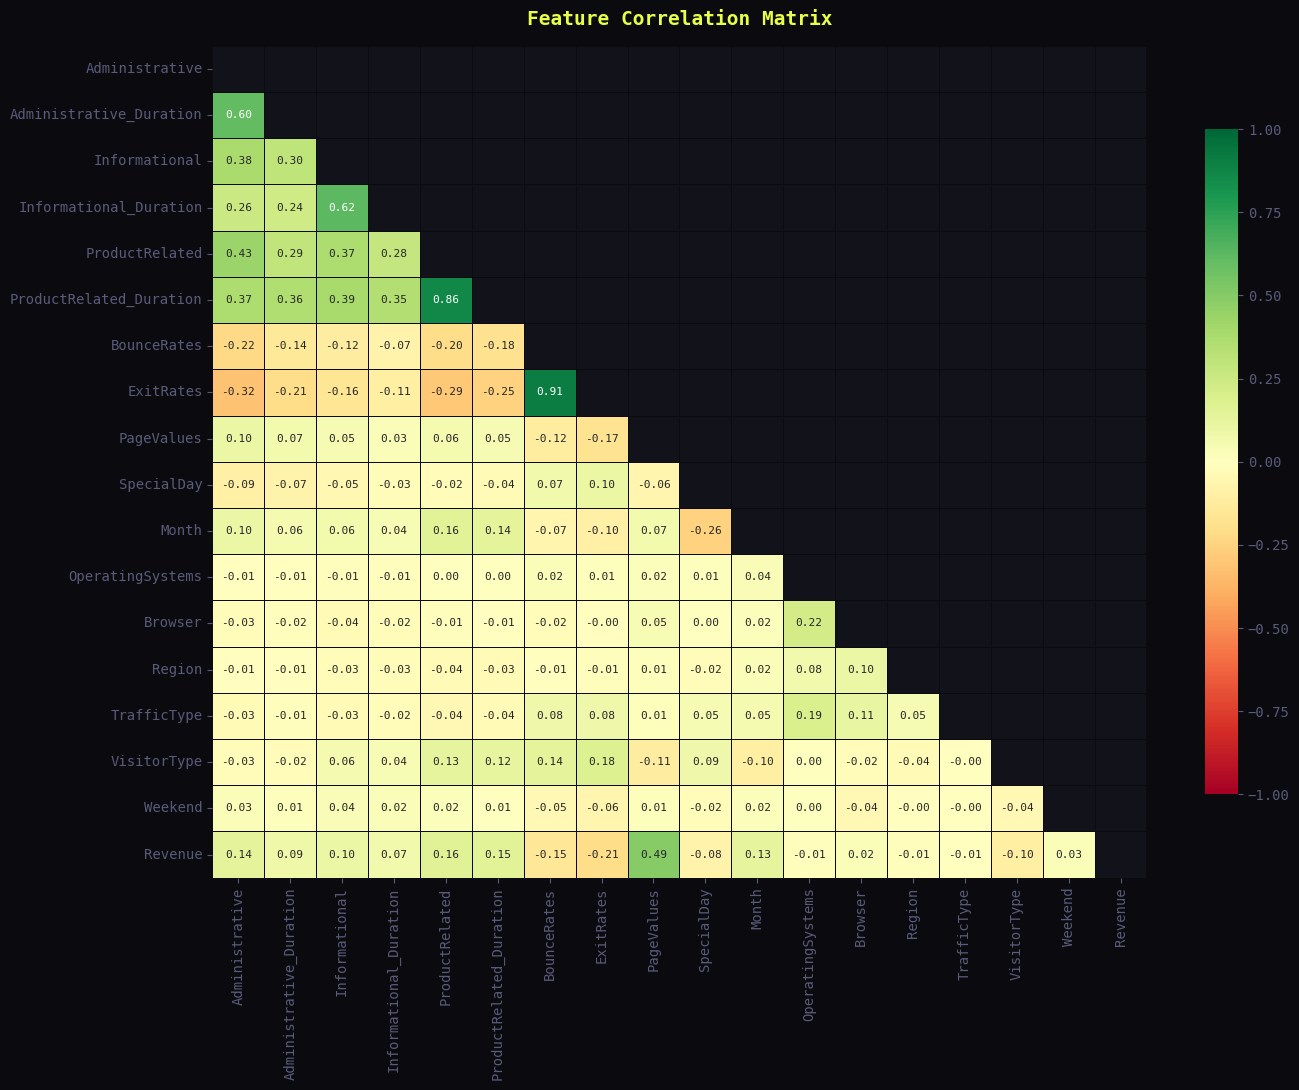

Top 10 features correlated with Revenue:
PageValues                 0.492569
ExitRates                 -0.207071
ProductRelated             0.158538
ProductRelated_Duration    0.152373
BounceRates               -0.150673
Administrative             0.138917
Month                      0.127372
VisitorType               -0.104726
Informational              0.095200
Administrative_Duration    0.093587


In [7]:
# Encode for correlation
df_enc = df.copy()
df_enc['Revenue']     = df_enc['Revenue'].astype(int)
df_enc['Weekend']     = df_enc['Weekend'].astype(int)
month_map = {
    'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'June':6,
    'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
}
df_enc['Month']       = df_enc['Month'].map(month_map)
df_enc['VisitorType'] = df_enc['VisitorType'].map(
    {'New_Visitor': 0, 'Other': 1, 'Returning_Visitor': 2}
)

numeric_cols = df_enc.select_dtypes(include=[np.number]).columns
corr         = df_enc[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='#0a0a0f',
    cbar_kws={'shrink': 0.8}
)
ax.set_title(
    'Feature Correlation Matrix',
    fontsize=14, fontweight='bold', color=ACCENT, pad=15
)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

# Print top correlations with target
target_corr = corr['Revenue'].drop('Revenue').sort_values(
    key=abs, ascending=False
)
print("Top 10 features correlated with Revenue:")
print(target_corr.head(10).to_string())

## 6. Bounce Rate vs Exit Rate — Combined Abandonment Risk

High bounce rate and high exit rate are both signals of low intent.  
Their combination (`ExitBounceRisk`) is one of our engineered features  
and appears consistently in the top SHAP features.

Bounce Rate — Buyers mean: 0.0051 | Non-buyers mean: 0.0253
Exit Rate — Buyers mean: 0.0196 | Non-buyers mean: 0.0474


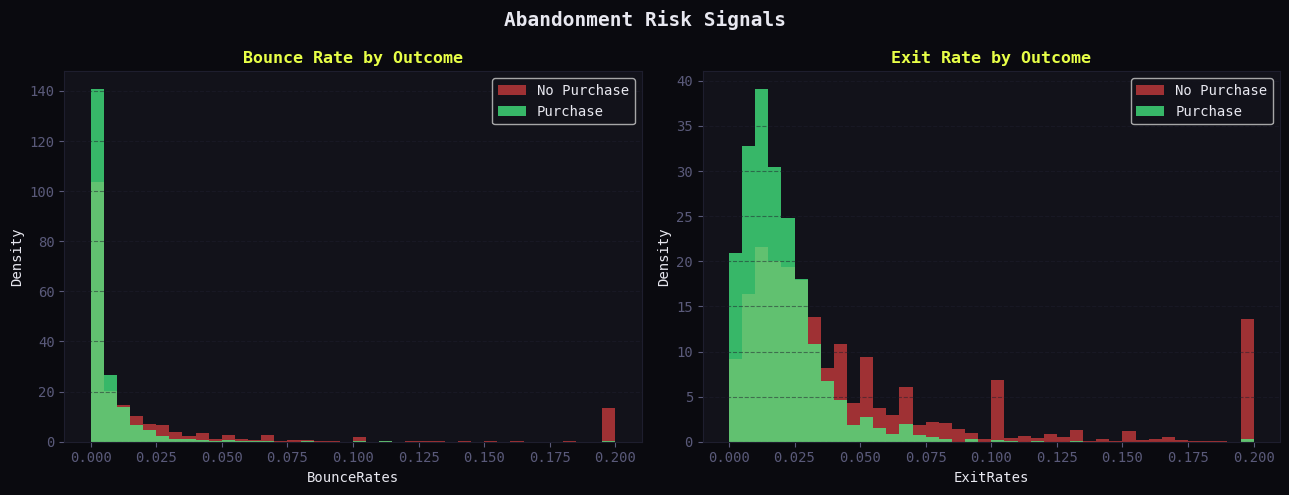

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['BounceRates', 'ExitRates'],
    ['Bounce Rate', 'Exit Rate']
):
    b = df[df['Revenue'] == True][col]
    nb = df[df['Revenue'] == False][col]
    ax.hist(nb, bins=40, color=DANGER,  alpha=0.6,
            label='No Purchase', density=True, edgecolor='none')
    ax.hist(b,  bins=40, color=CONVERT, alpha=0.7,
            label='Purchase',    density=True, edgecolor='none')
    ax.set_title(f'{title} by Outcome',
                  fontsize=12, fontweight='bold', color=ACCENT)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(axis='y')
    print(f"{title} — Buyers mean: {b.mean():.4f} | Non-buyers mean: {nb.mean():.4f}")

plt.suptitle('Abandonment Risk Signals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('abandonment_risk.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

## 7. Weekend vs Weekday Conversion

Weekend sessions have a marginally different conversion rate.  
The difference is small but consistent — included as a feature.

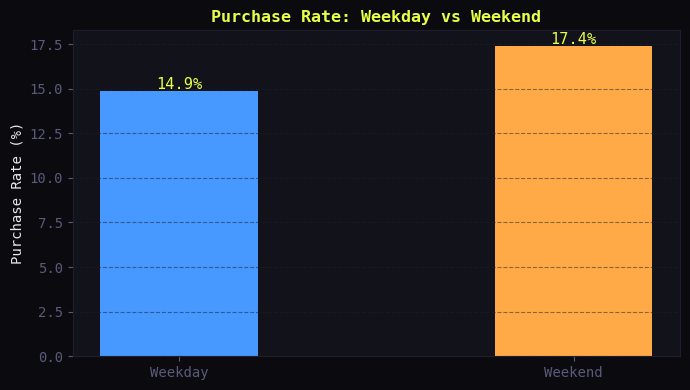

In [9]:
weekend_stats = df.groupby('Weekend').agg(
    total=('Revenue','count'),
    purchases=('Revenue','sum')
)
weekend_stats['rate'] = weekend_stats['purchases'] / weekend_stats['total'] * 100
weekend_stats.index   = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    weekend_stats.index, weekend_stats['rate'],
    color=[COLD, WARM], edgecolor='none', width=0.4
)
ax.set_title('Purchase Rate: Weekday vs Weekend',
              fontsize=12, fontweight='bold', color=ACCENT)
ax.set_ylabel('Purchase Rate (%)')
ax.grid(axis='y')
for bar, rate in zip(bars, weekend_stats['rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{rate:.1f}%',
        ha='center', fontsize=11, color=ACCENT
    )
plt.tight_layout()
plt.savefig('weekend_conversion.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

## 8. Key EDA Findings — Decisions Made

| Finding | Decision |
|---|---|
| 15.5% / 84.5% class imbalance | SMOTETomek in preprocessing + weighted loss in neural net |
| PageValues strongly separates classes | Kept as primary feature, HighPageValue flag engineered |
| November has highest conversion rate | Month encoded as ordinal integer, not dropped |
| Returning visitors convert 2x more | VisitorType encoded, used as bandit context feature |
| BounceRates + ExitRates both signal low intent | Combined into `ExitBounceRisk` engineered feature |
| ProductRelated pages dominate buyer sessions | `ProductPageRatio` engineered feature |
| No missing values | No imputation needed |

These findings directly motivated the 7 engineered features and all modelling choices in the pipeline.

In [10]:
print("EDA Complete.")
print("All plots saved to notebooks/ folder.")
print("\nKey numbers for the README:")
print(f"  Total sessions:     {len(df):,}")
print(f"  Buyers:             {df['Revenue'].sum():,} ({df['Revenue'].mean()*100:.1f}%)")
print(f"  Non-buyers:         {(~df['Revenue']).sum():,} ({(~df['Revenue']).mean()*100:.1f}%)")
print(f"  Imbalance ratio:    {(~df['Revenue']).sum() / df['Revenue'].sum():.1f}:1")
print(f"  Unique months:      {df['Month'].nunique()}")
print(f"  Visitor types:      {df['VisitorType'].unique()}")
print(f"  Missing values:     {df.isnull().sum().sum()}")

EDA Complete.
All plots saved to notebooks/ folder.

Key numbers for the README:
  Total sessions:     12,330
  Buyers:             1,908 (15.5%)
  Non-buyers:         10,422 (84.5%)
  Imbalance ratio:    5.5:1
  Unique months:      10
  Visitor types:      ['Returning_Visitor' 'New_Visitor' 'Other']
  Missing values:     0
